<a href="https://colab.research.google.com/github/Zurthr/tusas/blob/main/Tewsas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

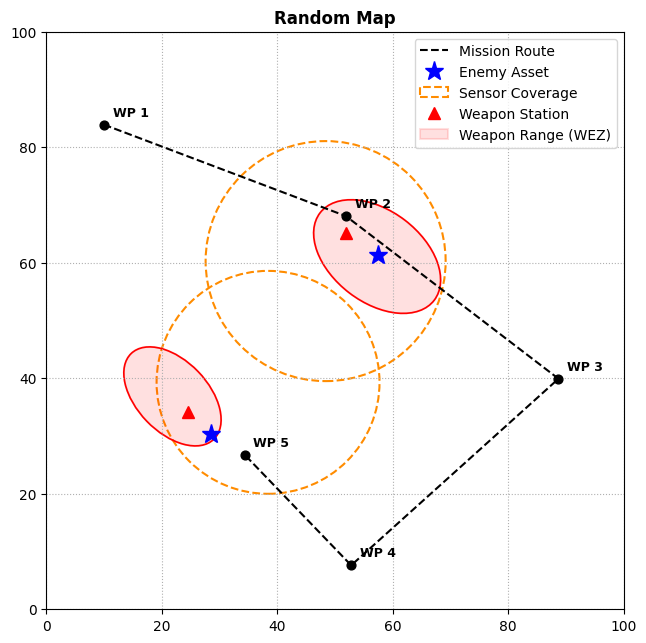

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.linalg as la

# Initialize randomization vıa seed
np.random.seed()

#Enemy asset
asset1_pos = (np.random.uniform(55, 75), np.random.uniform(45, 75))
asset2_pos = (np.random.uniform(25, 45), np.random.uniform(15, 45))
assets = [{"pos": asset1_pos, "label": "Asset 1"}, {"pos": asset2_pos, "label": "Asset 2"}]
sensors = [
    {"pos": (asset1_pos[0] + np.random.uniform(-10, 5), asset1_pos[1] + np.random.uniform(-10, 5)), "radius": np.random.uniform(20, 28)},
    {"pos": (asset2_pos[0] + np.random.uniform(-5, 10), asset2_pos[1] + np.random.uniform(-5, 10)), "radius": np.random.uniform(18, 25)}
]

weapons = [
    {"station": (asset1_pos[0] + np.random.uniform(-8, 8), asset1_pos[1] + np.random.uniform(-8, 8)), "a": np.random.uniform(11, 14), "b": np.random.uniform(7, 9), "offset": np.random.uniform(4, 7)},
    {"station": (asset2_pos[0] + np.random.uniform(-6, 6), asset2_pos[1] + np.random.uniform(-6, 6)), "a": np.random.uniform(9, 12), "b": np.random.uniform(5, 7), "offset": np.random.uniform(3, 6)}
]

# Flıght route generatıon
waypoints = np.array([
    [10, np.random.uniform(75, 90)],                                              # WP1 (Safe Start)
    [sensors[0]["pos"][0] + np.random.uniform(-5, 5), np.random.uniform(60, 70)], # WP2 (Near Sensor 1)
    [np.random.uniform(80, 95), np.random.uniform(25, 40)],                      # WP3 (Turn East)
    [np.random.uniform(45, 55), np.random.uniform(5, 15)],                       # WP4 (Inbound South)
    [sensors[1]["pos"][0] + np.random.uniform(-5, 5), np.random.uniform(25, 35)]  # WP5 (Extraction)
])

# Map scenarıo render
fig, ax1 = plt.subplots(figsize=(8, 7.5))

ax1.plot(waypoints[:, 0], waypoints[:, 1], 'k--', lw=1.5, label='Mission Route')
ax1.scatter(waypoints[:, 0], waypoints[:, 1], color='black', s=40, zorder=5)
for i, wp in enumerate(waypoints):
    ax1.text(wp[0] + 1.5, wp[1] + 1.5, f"WP {i+1}", fontsize=9, weight='bold')

for asset in assets:
    ax1.plot(asset["pos"][0], asset["pos"][1], 'b*', ms=14, label='Enemy Asset' if asset == assets[0] else "")

for i, sensor in enumerate(sensors):
    circle = patches.Circle(sensor["pos"], sensor["radius"], edgecolor='darkorange', facecolor='none', linestyle='--', lw=1.5, label='Sensor Coverage' if i == 0 else "")
    ax1.add_patch(circle)

for i, weapon in enumerate(weapons):
    xw, yw = weapon["station"]
    distances = [np.linalg.norm(np.mean([waypoints[j], waypoints[j+1]], axis=0) - [xw, yw]) for j in range(len(waypoints)-1)]
    current_leg = np.argmin(distances)
    p1, p2 = waypoints[current_leg], waypoints[current_leg + 1]
    angle_rad = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

    xc = xw + weapon["offset"] * np.cos(angle_rad)
    yc = yw + weapon["offset"] * np.sin(angle_rad)

    ax1.plot(xw, yw, 'r^', ms=9, label='Weapon Station' if i == 0 else "")
    ellipse = patches.Ellipse(xy=(xc, yc), width=weapon["a"]*2, height=weapon["b"]*2, angle=np.degrees(angle_rad), edgecolor='red', facecolor='red', alpha=0.12, lw=1.5, label='Weapon Range (WEZ)' if i == 0 else "")
    ax1.add_patch(ellipse)
    ellipse_outline = patches.Ellipse(xy=(xc, yc), width=weapon["a"]*2, height=weapon["b"]*2, angle=np.degrees(angle_rad), edgecolor='red', facecolor='none', lw=1.2)
    ax1.add_patch(ellipse_outline)

ax1.set_title("Random Map", fontsize=12, weight='bold')
ax1.set_xlim(0, 100); ax1.set_ylim(0, 100); ax1.grid(True, ls=':'); ax1.set_aspect('equal')
ax1.legend(loc='upper right')
plt.show()

State tracking graph, need to understand a bit

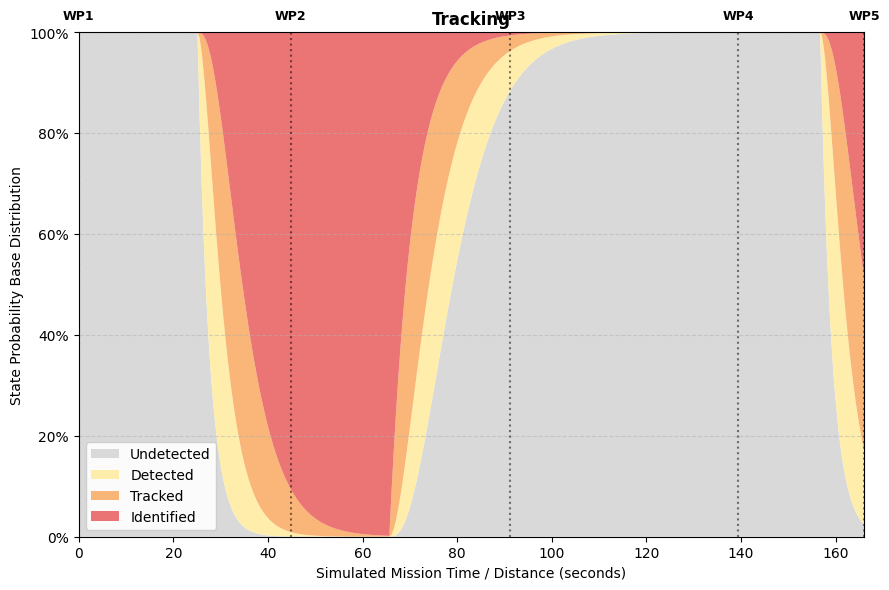

In [ ]:
# =========================================================
# CELL 2: MARKOV SIMULATION & STATE PROBABILITY DIAGRAM
# =========================================================

# 1. Sample the continuous flight path finely across legs
num_steps_per_leg = 100
path_points = []
for i in range(len(waypoints) - 1):
    leg = np.linspace(waypoints[i], waypoints[i+1], num_steps_per_leg, endpoint=False)
    path_points.extend(leg)
path_points.append(waypoints[-1])
path_points = np.array(path_points)

# Calculate elapsed step intervals assuming constant speed v = 1 unit/sec
segment_lengths = np.sqrt(np.sum(np.diff(path_points, axis=0)**2, axis=1))
time_steps = np.zeros(len(path_points))
time_steps[1:] = np.cumsum(segment_lengths)

# 2. Setup the Tracking States Matrix [Undetected, Detected, Tracked, Identified]
prob_history = np.zeros((len(path_points), 4))
prob_history[0] = [1.0, 0.0, 0.0, 0.0]  # Commences 100% undetected

# Transition parameter time values (from paper Table I)
tau_UD, tau_DT, tau_TT = 2.5, 3.3, 5.0  # Time to escalate right (inside radar)
tau_DU, tau_TD, tau_ID = 5.0, 5.0, 5.0  # Time to clear/regress left (outside radar)

# 3. Propagate state distributions dynamically along the trajectory coordinates
for t in range(1, len(path_points)):
    dt = time_steps[t] - time_steps[t-1]
    pos = path_points[t]

    # Evaluate sensor coverage geometry (Cartesian circle formula)
    sensors_covering = sum(1 for s in sensors if np.linalg.norm(pos - s["pos"]) <= s["radius"])

    # Construct infinitesimal generator matrix Λ
    Lambda = np.zeros((4, 4))
    if sensors_covering > 0:
        # Escalation transitions active inside radar coverage (scaled by overlap density)
        g_right = sensors_covering
        Lambda[0, 1] = g_right / tau_UD
        Lambda[1, 2] = g_right / tau_DT
        Lambda[2, 3] = g_right / tau_TT
    else:
        # Regression/forgetting transitions take over outside radar coverage
        Lambda[1, 0] = 1.0 / tau_DU
        Lambda[2, 1] = 1.0 / tau_TD
        Lambda[3, 2] = 1.0 / tau_ID

    # Apply row balance properties: Diagonals = -Sum(off-diagonals)
    for r in range(4):
        Lambda[r, r] = -np.sum(Lambda[r, :])

    # Calculate matrix exponential propagation: p(t) = p(t-dt) * e^(Λ * dt)
    prob_history[t] = prob_history[t-1] @ la.expm(Lambda * dt)

# 4. Generate Tracking State Probability Stacked Area Chart (Reproducing Figure 3)
fig, ax2 = plt.subplots(figsize=(9, 6))

ax2.stackplot(time_steps, prob_history[:, 0], prob_history[:, 1], prob_history[:, 2], prob_history[:, 3],
              labels=['Undetected', 'Detected', 'Tracked', 'Identified'],
              colors=['#d3d3d3', '#ffeb9c', '#f8a961', '#e85c5c'], alpha=0.85)

# Synchronize labels marking when waypoints occur chronologically on the timeline
wp_indices = [0] + [(j+1) * num_steps_per_leg for j in range(len(waypoints)-1)]
for idx, i in enumerate(wp_indices):
    t_val = time_steps[min(i, len(time_steps)-1)]
    ax2.axvline(x=t_val, color='black', linestyle=':', alpha=0.5)
    ax2.text(t_val, 1.02, f"WP{idx+1}", ha='center', va='bottom', fontsize=9, weight='bold')

ax2.set_title("Tracking", fontsize=12, weight='bold')
ax2.set_xlabel("Simulated Mission Time / Distance (seconds)")
ax2.set_ylabel("State Probability Base Distribution")
ax2.set_ylim(0, 1.0)
ax2.set_xlim(0, time_steps[-1])
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax2.legend(loc='lower left', framealpha=0.9)
ax2.grid(axis='y', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()